In [1]:
import scarf
from scarf.plotting import FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 79939451 / 79939451 complete

Downloading bytes: 79939451 / 79939451 complete

In [2]:
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
[wnn_umap] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
[wnn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": wnn_graph},
    complete_only=True,
)

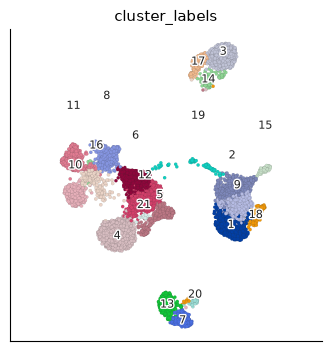

In [3]:
ds.plots.embedding(
    layout=wnn_umap,
    color_by=wnn_clusters,
    legend_loc="on_data",
)

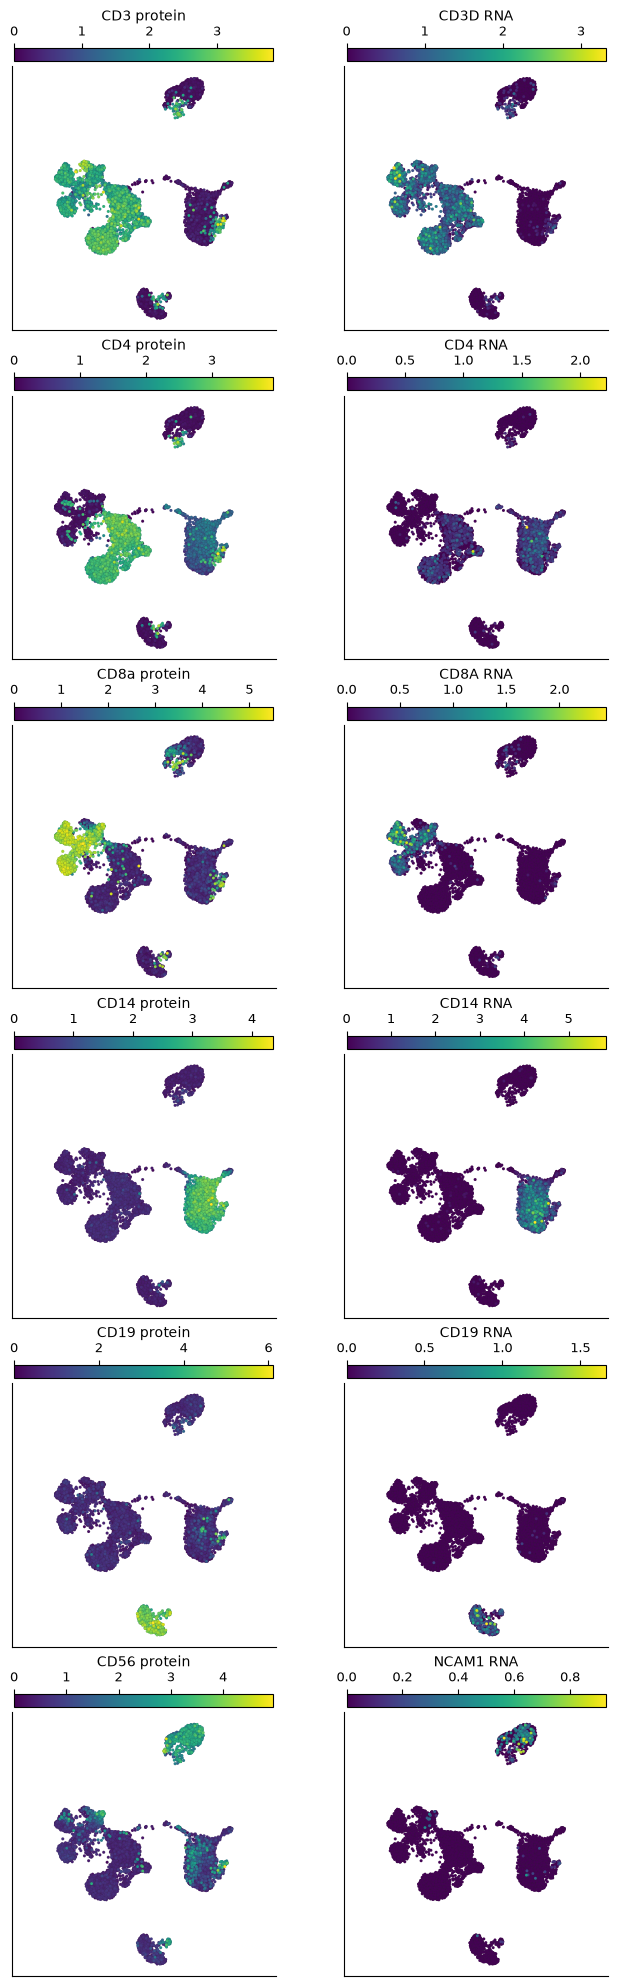

In [4]:
protein_panel = [
    FeatureRef(marker, assay="ADT", by="id", label=f"{marker} protein")
    for marker in ("CD3", "CD4", "CD8a", "CD14", "CD19", "CD56")
]
rna_panel = [
    FeatureRef(gene, assay="RNA", label=f"{gene} RNA")
    for gene in ("CD3D", "CD4", "CD8A", "CD14", "CD19", "NCAM1")
]
paired_panel = [
    panel for pair in zip(protein_panel, rna_panel, strict=True) for panel in pair
]
ds.plots.embedding(
    layout=wnn_umap,
    color_by=paired_panel,
    n_columns=2,
    sort_values=True,
)